## Q13 - HR Employee Data EDA & Analysis

--- Dataset Shape ---
Total employees: 14999
Total features: 11

--- Missing Values ---
Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Overall Turnover Rate: 23.8%

--- Profile of 'Burnout' employees leaving ---
Average projects: 6.2
Average monthly hours: 276


C:\Users\OGK19\AppData\Local\Temp\ipykernel_22620\1973472413.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='salary', y='left', order=['low', 'medium', 'high'],
C:\Users\OGK19\AppData\Local\Temp\ipykernel_22620\1973472413.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='number_project', y='left', errorbar=None,
C:\Users\OGK19\AppData\Local\Temp\ipykernel_22620\1973472413.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Department', y='left', errorbar=None,


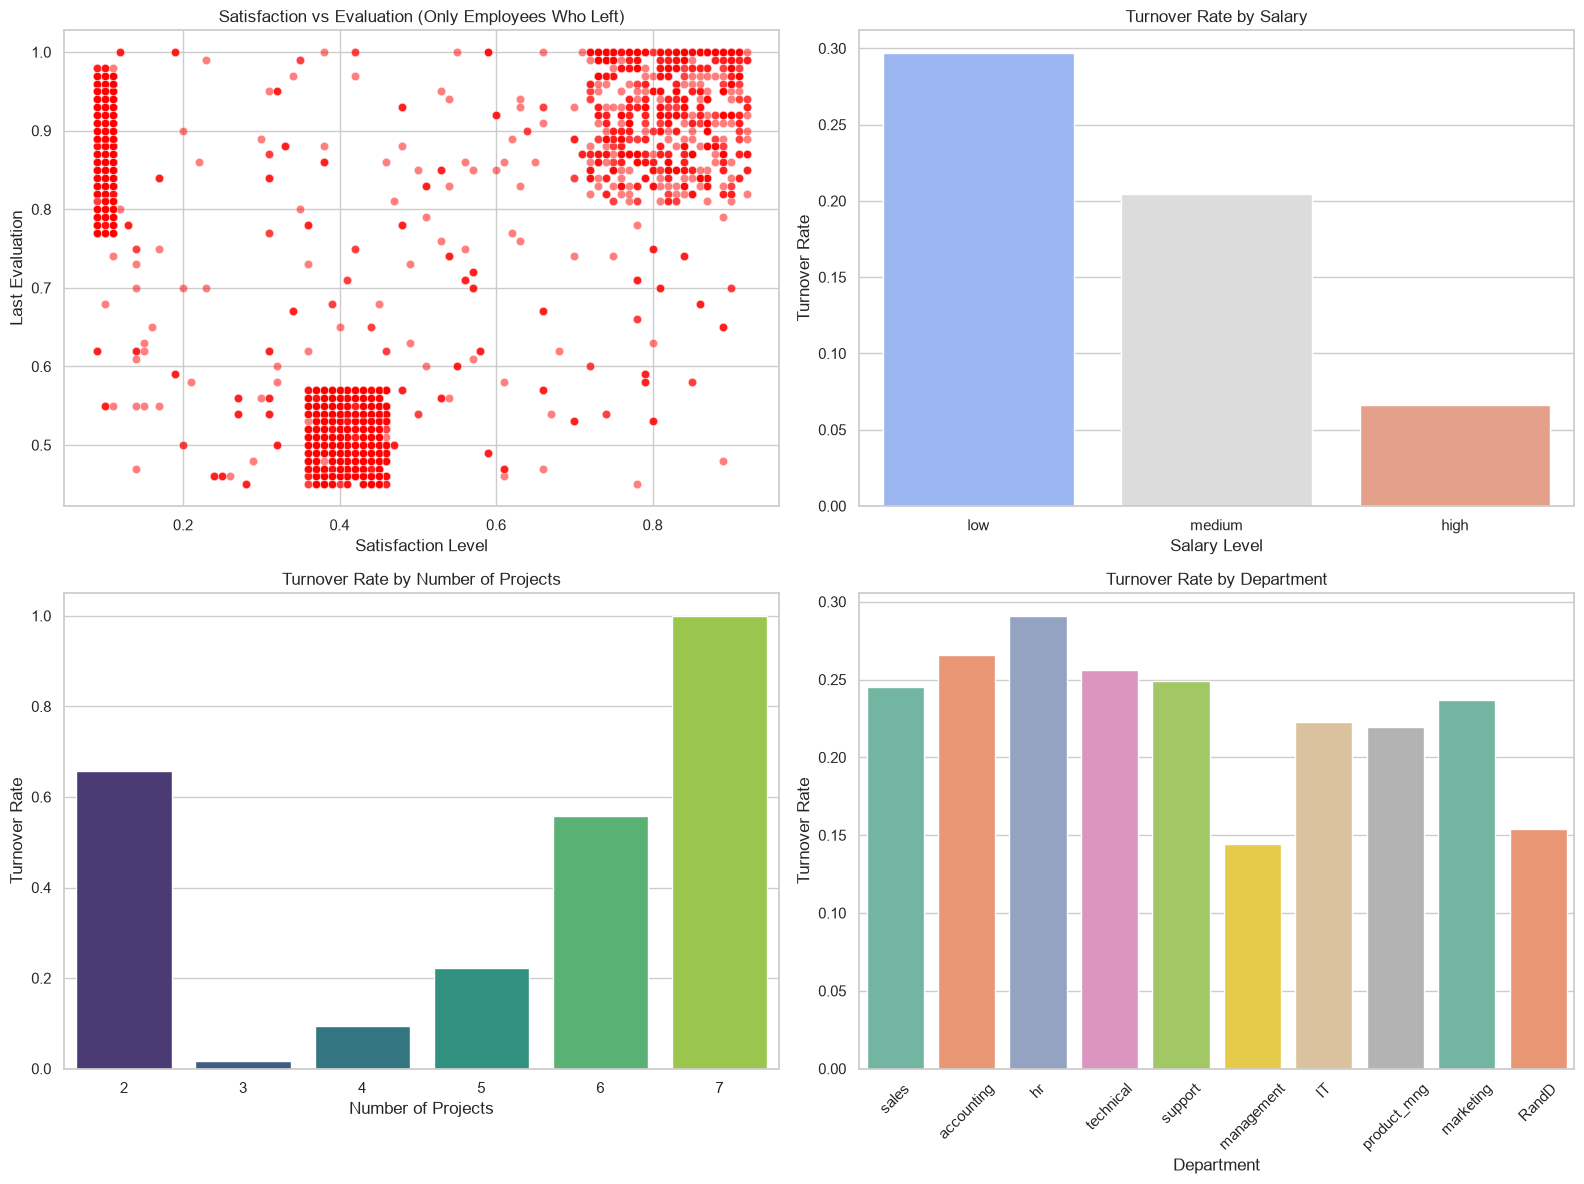

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset from the Excel file
df = pd.read_excel('Datasets/hr_employee_data.xlsx', sheet_name='HR_Employee_Data')

# 2. General Data Overview
print("--- Dataset Shape ---")
print(f"Total employees: {df.shape[0]}")
print(f"Total features: {df.shape[1]}\n")

# Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# Calculate the overall turnover rate
turnover_rate = df['left'].mean()
print(f"\nOverall Turnover Rate: {turnover_rate:.1%}")

# 3. Create clusters to understand WHY people leave based on satisfaction and evaluation
left_df = df[df['left'] == 1]

# Filter out the three distinct groups of employees who leave
burnout = left_df[(left_df['satisfaction_level'] < 0.2) & (left_df['last_evaluation'] > 0.75)]
underperformers = left_df[(left_df['satisfaction_level'] >= 0.3) & (left_df['satisfaction_level'] <= 0.5) & (left_df['last_evaluation'] <= 0.6)]
stars = left_df[(left_df['satisfaction_level'] > 0.7) & (left_df['last_evaluation'] > 0.8)]

print("\n--- Profile of 'Burnout' employees leaving ---")
print(f"Average projects: {burnout['number_project'].mean():.1f}")
print(f"Average monthly hours: {burnout['average_montly_hours'].mean():.0f}")

# 4. Data Visualization 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot A: Satisfaction vs. Evaluation (The 3 Clusters)
sns.scatterplot(data=left_df, x='satisfaction_level', y='last_evaluation', 
                alpha=0.5, color='red', ax=axes[0, 0])
axes[0, 0].set_title('Satisfaction vs Evaluation (Only Employees Who Left)')
axes[0, 0].set_xlabel('Satisfaction Level')
axes[0, 0].set_ylabel('Last Evaluation')

# Plot B: Turnover by Salary Level
sns.barplot(data=df, x='salary', y='left', order=['low', 'medium', 'high'], 
            errorbar=None, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Turnover Rate by Salary')
axes[0, 1].set_ylabel('Turnover Rate')
axes[0, 1].set_xlabel('Salary Level')

# Plot C: Turnover by Number of Projects (Workload)
sns.barplot(data=df, x='number_project', y='left', errorbar=None, 
            palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Turnover Rate by Number of Projects')
axes[1, 0].set_ylabel('Turnover Rate')
axes[1, 0].set_xlabel('Number of Projects')

# Plot D: Turnover by Department
sns.barplot(data=df, x='Department', y='left', errorbar=None, 
            palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Turnover Rate by Department')
axes[1, 1].set_ylabel('Turnover Rate')
axes[1, 1].set_xlabel('Department')
axes[1, 1].tick_params(axis='x', rotation=45)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

### Analysis

***Initial takeaway***

We've got three type of employees: Burntout stars, the unenganged/jaded and the Fleeing stars. 

Burnt out stars: These employees are highly skilled and perform really well, but are highly 
dissatisfied and highly overworked. 

The unengaged/jaded: These employees are low performers and highly dissatisfied. 
Losing there employees isn't necessarily a bad thing, since they can be replaced
with fresher, more motivated blood. But it's still noteworthy.

The fleeing stars: Highly skilled, high satisfaction. These employees work well and they
enjoy their place of work, but still choose to quit. They are most likely getting head hunted 
by our competitors. 


***Workload sweetspot***

The "*Turnover by Number of Projects*" graph shows a clear correlation between
the amount of projects and turnover rate.

Any employee with 7 projects at once are almost garaunteed to throw in the hat. 
Which is understandable, it's more than likely too much work. These employees 
might feel like they're being taking advantage of by the company or their
fellow co-workers. 

On the flip side, any employee with only 2 projects are more than +60% likely
to turn in their two week notice. Maybe they feel as if their talents are being
wasted or that they are being prhobited from developing in their career.

The sweetspot seems to be a maximum of 3-4 projects/employee. 
It should be possible to more fairly deligate project workload to keep 
employees... well, employed.

***Salaries***

Unsuprisingly, the salary does affect wether or not an employee decieds 
to venture out. The turnover rate for employees with a "low" salary where ~30%, turnover rate
for employees with a "medium" salary was ~20% and respectively only ~6% for
employees with a "high" salary.

***Vulnerable departments***

The turnover rate for the different departments are noticeably. 
The facts show that: 

* HR has a ~29% turnover rate
* Accounting has a ~26% turnover rate
* While management only has a ~14% turnover rate


***Recommendations to management***

* Implement a cap on the amount of projects a single employee is 
allowed to work on at a time.
* Evaluate if the salary for the "fleeing stars" can be adjusted
* Investiage **why** the HR and accounting departments are in shambles.

Remember, retaining employees are **ALOT** cheaper than hiring new ones.
Especially hiring new ones every year.

## Q16 - Complete ML flow, modelling diamond prices

RMSE: 646.73
R2 Score: 0.9737


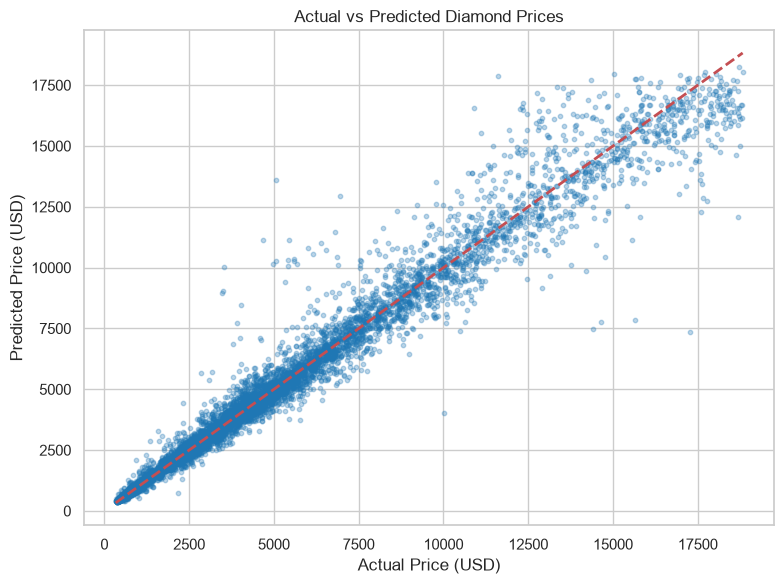

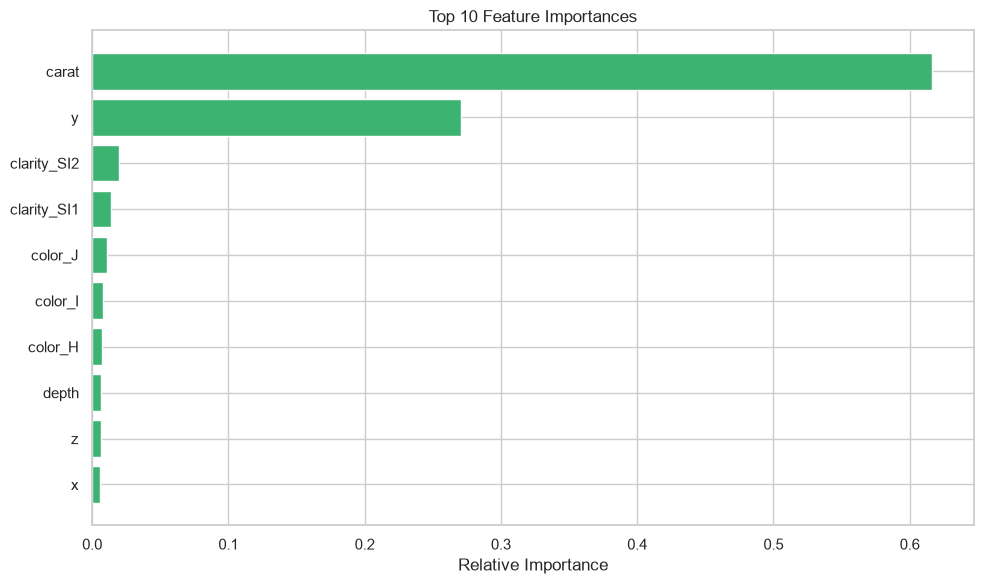

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Datasets/diamonds.csv')

# Drop the redundant index column if it exists in the dataset
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Separate the target variable (price) from the features
X = df.drop('price', axis=1)
y = df['price']

# Define which columns are numerical and which are categorical
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']

# Create a preprocessor to scale numerical features and encode categorical ones
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Build a machine learning pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
])

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model using the training data
pipeline.fit(X_train, y_train)

# Make price predictions on the unseen test data
y_pred = pipeline.predict(X_test)

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

# Plot 1: Actual vs Predicted
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='#1f77b4', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted Diamond Prices')
plt.tight_layout()

# Display the first plot
plt.show() 

# Plot 2: Feature Importance (extracting from pipeline)
model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['preprocessor']
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(encoded_cat_cols)

importances = model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='mediumseagreen', align='center')
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Top 10 Feature Importances')
plt.tight_layout()

# Display the second plot
plt.show()

### Result and evaluation

When running the model on the test data, it generates the following:
*Note: Results may vary, it depends on if I don't forget to save the model lol*

* **R2 Score (0.9737)**: The model kan explain ~97.4% of variance in the diamond prices 
which indicate a pretty high accuracy.
* **RMSE (646.73)**: The predicted prices deviate on average by ~647$ from the actual 
prices. Which isn't alot considering some diamonds in the dataset can cost upwards of
20,000$ (USD).

To visualize how well the model performs and which characteristics influence the
price the most, we can take a look at two graphs.

***First Graph, Acutal vs predict price***

The dots in this first graph are trying to follow the dashed line (- - -), which
confirms that that model does consecutive pricing for both "cheap" and expensive
diamonds. A certain spread does occour at the really high prices.

***Second graph, Feature importance***

If you may please consult the graph, you shall find that the single most
important deciding factor for the price of a diamond, is actually, yes indeed,
the **carat**. Crazy idea right? :D